In [1]:
import pandas as pd

df_revenus = pd.read_csv(
 'https://www.data.gouv.fr/api/1/datasets/r/516130bc-4dcb-47f5-8347-ae96553c43ab',sep=';'
)

print(f"Shape : {df_revenus.shape}")
df_revenus.sample(5)

Shape : (34926, 57)


/tmp/ipykernel_73837/2966904175.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_revenus = pd.read_csv(


,Nom géographique GMS,Code géographique,Libellé géographique,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Nbre d'unités de consommation dans les ménages fiscaux,[DISP] 1ᵉʳ quartile (€),[DISP] Médiane (€),[DISP] 3ᵉ quartile (€),[DISP] Écart interquartile (€),...,[DEC] 9ᵉ décile (€),[DEC] Rapport interdécile D9/D1,[DEC] S80/S20,[DEC] Iice de Gini,[DEC] Part des revenus d’activité (%),[DEC] dont part des salaires et traitements (%),[DEC] dont part des iemnités de chômage (%),[DEC] dont part des revenus des activités non salariées (%),"[DEC] Part des pensions, retraites et rentes (%)",[DEC] Part des autres revenus (%)
5688,Cramchaban,17132,Cramchaban,276.0,705.0,465.4,NaN,21800.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18759,Vitry-la-Ville,51648,Vitry-la-Ville,141.0,389.0,250.8,NaN,24030.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33771,Suriauville,88461,Suriauville,95.0,222.0,150.3,NaN,22530.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31419,Ham,80410,Ham,2009.0,4177.0,2959.6,12630.0,17450.0,23230.0,10600.0,...,30970.0,"14,1",15.3,0.405,58.0,51.1,4.3,2.6,38.2,3.8
32171,Escazeaux,82053,Escazeaux,119.0,287.0,192.2,NaN,22380.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
list(df_revenus.columns)

['Nom géographique GMS',
 'Code géographique',
 'Libellé géographique',
 '[DISP] Nbre de ménages fiscaux',
 '[DISP] Nbre de personnes dans les ménages fiscaux',
 "[DISP] Nbre d'unités de consommation dans les ménages fiscaux",
 '[DISP] 1ᵉʳ quartile (€)',
 '[DISP] Médiane (€)',
 '[DISP] 3ᵉ quartile (€)',
 '[DISP] Écart interquartile (€)',
 '[DISP] 1ᵉʳ décile (€)',
 '[DISP] 2ᵉ décile (€)',
 '[DISP]3ᵉ décile (€)',
 '[DISP] 4ᵉ décile (€)',
 '[DISP] 6ᵉ décile (€)',
 '[DISP] 7ᵉ décile (€)',
 '[DISP] 8ᵉ décile (€)',
 '[DISP] 9ᵉ décile (€)',
 '[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile',
 '[DISP] S80/20',
 '[DISP] Iice de Gini',
 '[DISP] Part des revenus d’activité (%)',
 '[DISP] dont part des salaires et traitements(%)',
 '[DISP] dont part des iemnités de chômage (%)',
 '[DISP] dont part des revenus des activités non salariées (%)',
 '[DISP] Part des pensions, retraites et rentes (%)',
 '[DISP] Part des revenus du patrimoine et autres revenus (%)',
 "[DISP] Part de l'ensemble des prestat

signification des préfixes
[DISP]

👉 Revenu disponible des ménages.
C’est le revenu après impôts directs + prestations sociales.

Donc proche du pouvoir d’achat réel.

[DEC]

👉 Revenu déclaré / fiscal avant redistribution complète (selon source/table précise).
Souvent utilisé pour la structure fiscale.


Différence utile :

Pour analyser consommation / adoption VE :

👉 [DISP] est souvent plus pertinent que [DEC]

📘 Signification des variables principales
Identifiants géographiques
Nom géographique GMS : nom de la zone
Code géographique : code INSEE / code zone
Libellé géographique : nom officiel
👨‍👩‍👧 Taille / population fiscale
Nbre de ménages fiscaux : nombre de foyers fiscaux
Nbre de personnes dans les ménages fiscaux
Nbre d'unités de consommation

👉 utile pour normaliser les données

💶 Niveau de vie
1er quartile : 25% gagnent moins
Médiane : revenu central
3e quartile : 75% gagnent moins

👉 excellent indicateur de richesse locale

📊 Dispersion / inégalités
Écart interquartile = Q3 - Q1
Déciles D1 à D9
Rapport interdécile D9/D1
S80/20 : revenus des 20% les plus riches / 20% les plus pauvres
Indice de Gini

👉 mesure des inégalités

💼 Origine des revenus
Part des revenus d’activité
Part salaires
Part chômage
Part activités non salariées
Part pensions / retraites
Part patrimoine
Part prestations sociales
Part minima sociaux
Part logement
Part impôts

👉 structure socio-économique locale

Gini = vision globale
D9/D1 = contraste riches/pauvres lisible

On choisit donc de garder pour la modélisation :
['[DISP] Médiane (€)',
 '[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile',
 '[DISP] Iice de Gini',
 '[DISP] Nbre de ménages fiscaux',
 #population
 '[DISP] Nbre de personnes dans les ménages fiscaux'
 #zone dynamique économiquement
 '[DISP] Part des revenus d’activité (%)'
 #plus pauvre
 '[DISP] dont part des iemnités de chômage (%)'
 "[DISP] Part de l'ensemble des prestations sociales (%)"
 #plus riche
 '[DISP] dont part des revenus des activités non salariées (%)'
 '[DISP] Part des revenus du patrimoine et autres revenus (%)'
 #plus vieux
 '[DISP] Part des pensions, retraites et rentes (%)'
]

à créer :
Ratio actifs / retraités
part_activite / part_retraites
👉 dynamisme démographique.

3. Indice de précarité
chomage + minima_sociaux + prestations_sociales
(normalisé)

In [17]:
var_selec = [
'[DISP] Médiane (€)',
 '[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile',
 '[DISP] Iice de Gini',
 '[DISP] Nbre de ménages fiscaux',
 #population
 '[DISP] Nbre de personnes dans les ménages fiscaux',
 #zone dynamique économiquement
 '[DISP] Part des revenus d’activité (%)',
 #plus pauvre
 '[DISP] dont part des iemnités de chômage (%)',
 "[DISP] Part de l'ensemble des prestations sociales (%)",
 #plus riche
 '[DISP] dont part des revenus des activités non salariées (%)',
 '[DISP] Part des revenus du patrimoine et autres revenus (%)',
 #plus vieux
 '[DISP] Part des pensions, retraites et rentes (%)'
]

df_filtre = df_revenus[var_selec]
df_filtre.sample(5)

,[DISP] Médiane (€),[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile,[DISP] Iice de Gini,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Part des revenus d’activité (%),[DISP] dont part des iemnités de chômage (%),[DISP] Part de l'ensemble des prestations sociales (%),[DISP] dont part des revenus des activités non salariées (%),[DISP] Part des revenus du patrimoine et autres revenus (%),"[DISP] Part des pensions, retraites et rentes (%)"
559,18580.0,3.4,0.281,5358.0,10997.0,61.8,3.3,11.6,4.3,5.4,34.2
27000,27080.0,3.6,0.303,1085.0,2568.0,83.8,2.6,3.6,4.8,11.5,21.9
11920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21097,23180.0,NaN,NaN,252.0,570.0,NaN,NaN,NaN,NaN,NaN,NaN
33025,26820.0,2.6,0.249,1511.0,3734.0,76.0,1.4,3.0,4.9,10.5,28.2


In [18]:
df_filtre.dtypes

[DISP] Médiane (€)                                              float64
[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile                 float64
[DISP] Iice de Gini                                             float64
[DISP] Nbre de ménages fiscaux                                  float64
[DISP] Nbre de personnes dans les ménages fiscaux               float64
[DISP] Part des revenus d’activité (%)                          float64
[DISP] dont part des iemnités de chômage (%)                    float64
[DISP] Part de l'ensemble des prestations sociales (%)          float64
[DISP] dont part des revenus des activités non salariées (%)    float64
[DISP] Part des revenus du patrimoine et autres revenus (%)     float64
[DISP] Part des pensions, retraites et rentes (%)               float64
dtype: object

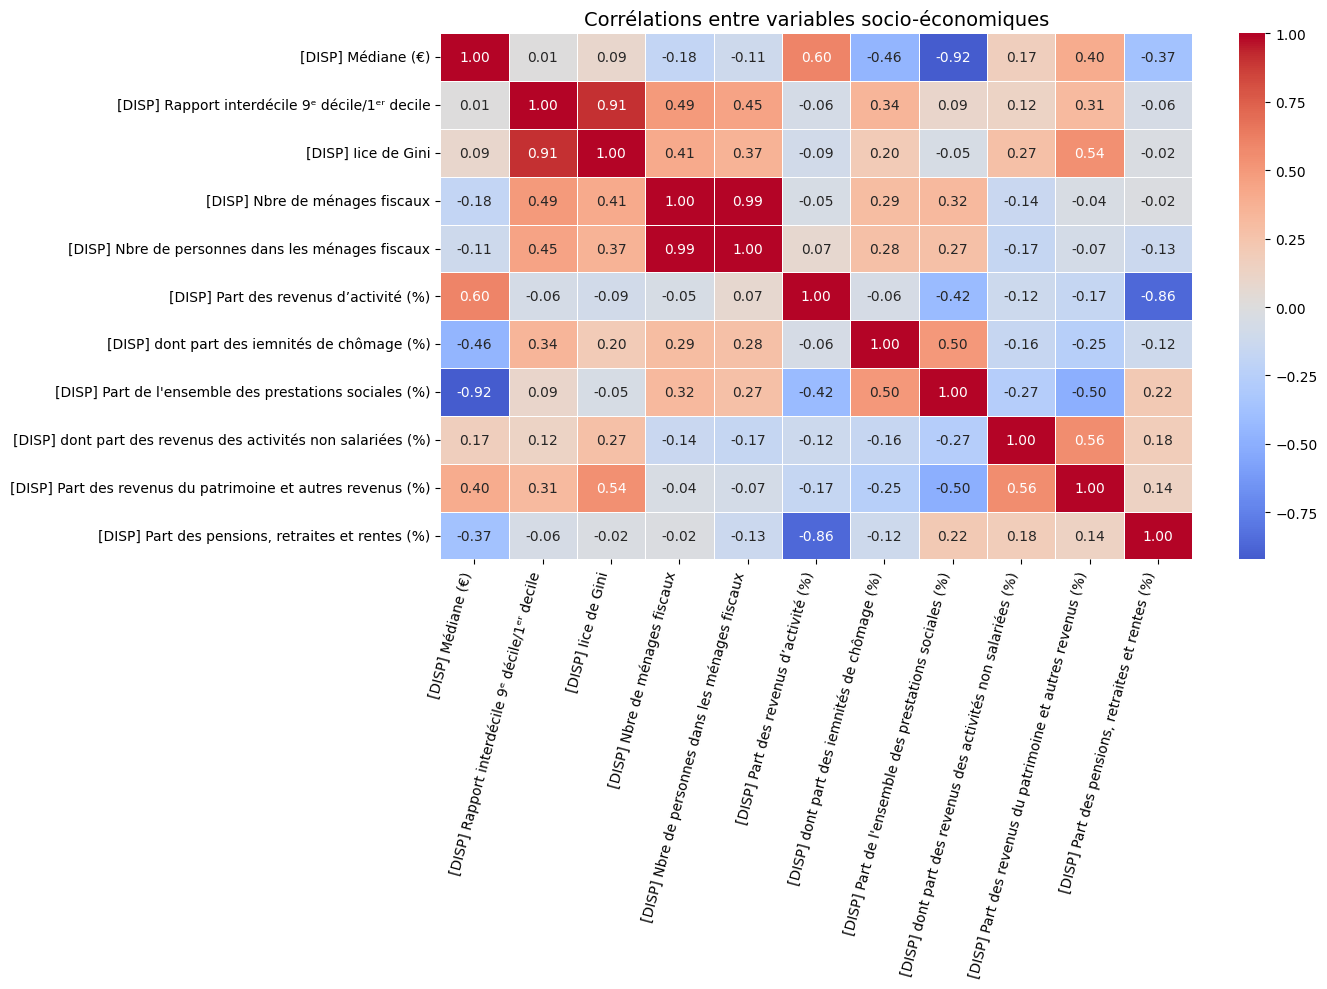


===== CORRELATIONS FORTES (>|0.70|) =====
[DISP] Iice de Gini  <-->  [DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile : 0.91
[DISP] Nbre de personnes dans les ménages fiscaux  <-->  [DISP] Nbre de ménages fiscaux : 0.99
[DISP] Part de l'ensemble des prestations sociales (%)  <-->  [DISP] Médiane (€) : -0.92
[DISP] Part des pensions, retraites et rentes (%)  <-->  [DISP] Part des revenus d’activité (%) : -0.86


In [ ]:
# ==========================================================
# ETUDE DES CORRELATIONS - Variables socio-économiques
# DataFrame supposé : df
# ==========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 2. Création dataframe numérique propre
# ----------------------------------------------------------

df_corr = df_filtre.copy()

# suppression lignes vides
df_corr = df_corr.dropna()

# ----------------------------------------------------------
# 3. Matrice de corrélation Spearman
# ----------------------------------------------------------

corr_matrix = df_corr.corr(method='spearman')

# ----------------------------------------------------------
# 4. Heatmap lisible
# ----------------------------------------------------------

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Corrélations entre variables socio-économiques", fontsize=14)
plt.xticks(rotation=75, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 5. Corrélations fortes uniquement
# ----------------------------------------------------------

print("\n===== CORRELATIONS FORTES (>|0.70|) =====")

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.70:
            print(
                f"{corr_matrix.columns[i]}  <-->  "
                f"{corr_matrix.columns[j]} : {val:.2f}"
            )


Finalement on va garder :

var_selec = [
'[DISP] Médiane (€)',
 '[DISP] Iice de Gini',
 #garder uniquement l'un des deux
 '[DISP] Nbre de ménages fiscaux',
 '[DISP] Nbre de personnes dans les ménages fiscaux',
 #zone dynamique économiquement (potentiellement plus jeune aussi)
 '[DISP] Part des revenus d’activité (%)',
 #plus riche
 '[DISP] dont part des revenus des activités non salariées (%)',
 '[DISP] Part des revenus du patrimoine et autres revenus (%)',
]